Variable Name	Description	Type
SeriousDlqin2yrs	Person experienced 90 days past due delinquency or worse 	Y/N
RevolvingUtilizationOfUnsecuredLines	Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits	percentage
age	Age of borrower in years	integer
NumberOfTime30-59DaysPastDueNotWorse	Number of times borrower has been 30-59 days past due but no worse in the last 2 years.	integer
DebtRatio	Monthly debt payments, alimony,living costs divided by monthy gross income	percentage
MonthlyIncome	Monthly income	real
NumberOfOpenCreditLinesAndLoans	Number of Open loans (installment like car loan or mortgage) and Lines of credit (e.g. credit cards)	integer
NumberOfTimes90DaysLate	Number of times borrower has been 90 days or more past due.	integer
NumberRealEstateLoansOrLines	Number of mortgage and real estate loans including home equity lines of credit	integer
NumberOfTime60-89DaysPastDueNotWorse	Number of times borrower has been 60-89 days past due but no worse in the last 2 years.	integer
NumberOfDependents	Number of dependents in family excluding themselves (spouse, children etc.)	integer


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import seaborn as sns 


In [32]:
df = pd.read_csv("src/cs-training.csv").drop(['Unnamed: 0'], axis=1)
df = df.rename(columns={"SeriousDlqin2yrs": "target"})

## 2. Data Analysis

In [33]:
df.isnull().sum()*100/df.shape[0]


target                                   0.000000
RevolvingUtilizationOfUnsecuredLines     0.000000
age                                      0.000000
NumberOfTime30-59DaysPastDueNotWorse     0.000000
DebtRatio                                0.000000
MonthlyIncome                           19.820667
NumberOfOpenCreditLinesAndLoans          0.000000
NumberOfTimes90DaysLate                  0.000000
NumberRealEstateLoansOrLines             0.000000
NumberOfTime60-89DaysPastDueNotWorse     0.000000
NumberOfDependents                       2.616000
dtype: float64

In [34]:
print(df.columns.tolist())
print(df.shape)
print(df.describe().T[["mean", "std", "min", "max"]])

['target', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
(150000, 11)
                                             mean           std  min  \
target                                   0.066840      0.249746  0.0   
RevolvingUtilizationOfUnsecuredLines     6.048438    249.755371  0.0   
age                                     52.295207     14.771866  0.0   
NumberOfTime30-59DaysPastDueNotWorse     0.421033      4.192781  0.0   
DebtRatio                              353.005076   2037.818523  0.0   
MonthlyIncome                         6670.221237  14384.674215  0.0   
NumberOfOpenCreditLinesAndLoans          8.452760      5.145951  0.0   
NumberOfTimes90DaysLate                  0.265973      4.169304  0.0   
NumberRealEstateLoansOrLines             1.018240      

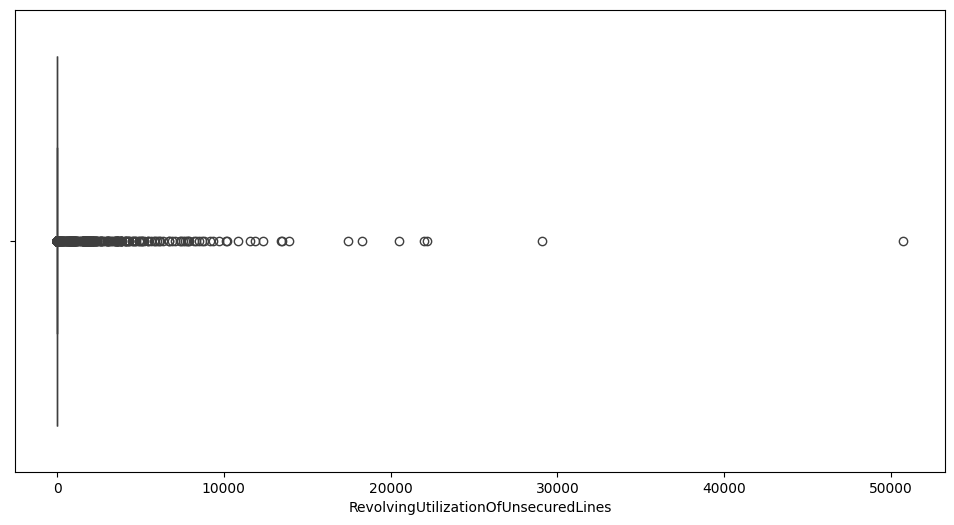

In [35]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(x=df['RevolvingUtilizationOfUnsecuredLines'], ax=ax);

<Axes: >

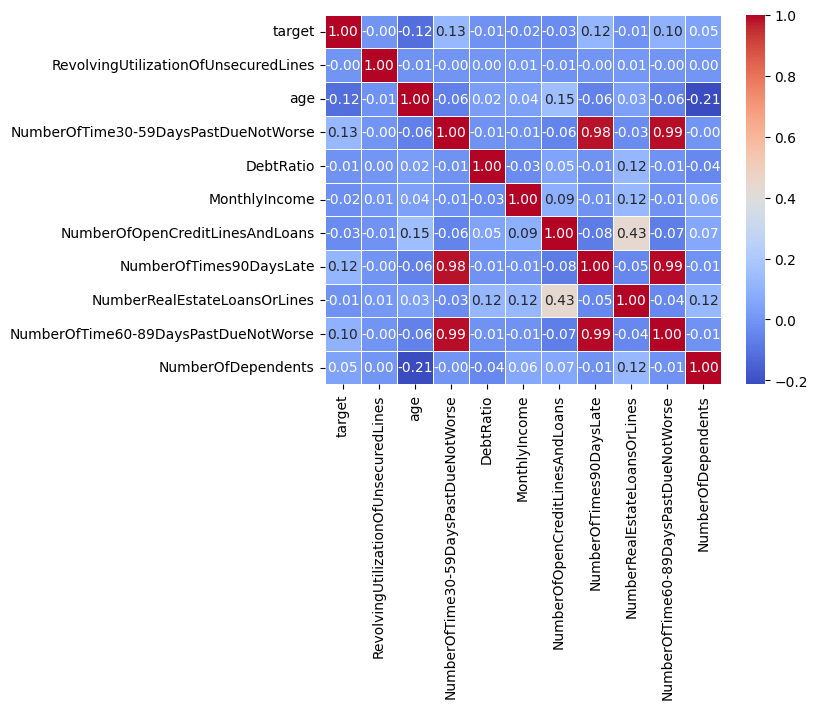

In [36]:
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)


## Stage 2 — Chi-Square Missing Predictiveness


Таблица сопряжённости для [MonthlyIncome]:
target           0     1
is_missing              
0           111912  8357
1            28062  1669

Таблица сопряжённости для [NumberOfDependents]:
target           0     1
is_missing              
0           136229  9847
1             3745   179

── Итоговый отчёт ───────────────────────────────────────────
           feature  n_missing pct_missing  dr_present  dr_missing  dr_lift  chi2  p_value  predictive        recommendation
     MonthlyIncome      29731       19.8%      0.0695      0.0561     0.81 67.89      0.0        True 🟡 MNAR — создать флаг
NumberOfDependents       3924        2.6%      0.0674      0.0456     0.68 28.75      0.0        True 🟡 MNAR — создать флаг

Создан флаг: MonthlyIncome_missing_flag
MonthlyIncome_missing_flag
0    120269
1     29731
Name: count, dtype: int64

Создан флаг: NumberOfDependents_missing_flag
NumberOfDependents_missing_flag
0    146076
1      3924
Name: count, dtype: int64
Заполнен MonthlyIncome мед

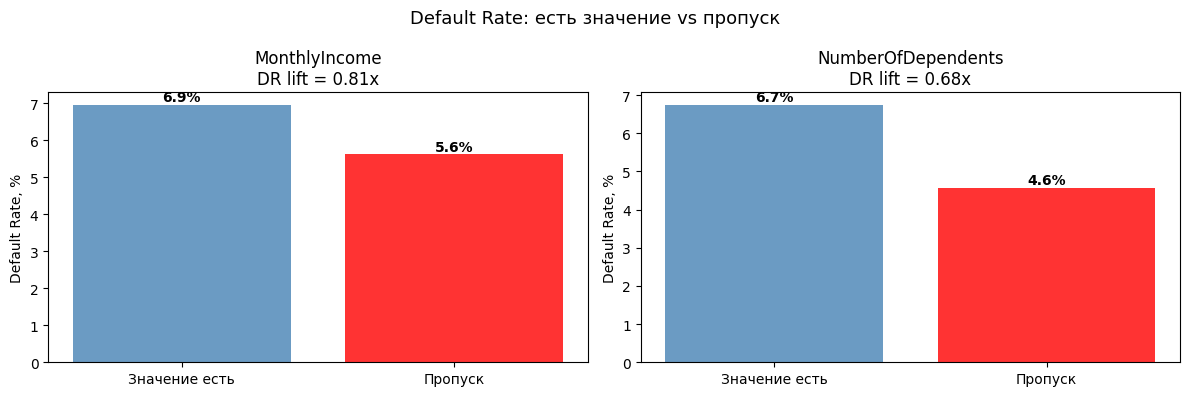

In [37]:
def missing_chi2_test(df, feature, target):
    tmp = df[[feature, target]].copy()
    tmp["is_missing"] = tmp[feature].isna().astype(int)

    n_missing = tmp["is_missing"].sum()

    ct = pd.crosstab(tmp["is_missing"], tmp[target])
    print(f"\nТаблица сопряжённости для [{feature}]:")
    print(ct)

    chi2, p, _, _ = chi2_contingency(ct)

    # DR у тех у кого пропуск vs у кого есть значение
    dr_missing = tmp[tmp["is_missing"] == 1][target].mean()
    dr_present = tmp[tmp["is_missing"] == 0][target].mean()
    dr_lift    = dr_missing / (dr_present + 1e-9)

    return {
        "feature":     feature,
        "n_missing":   n_missing,
        "pct_missing": f"{n_missing / len(tmp):.1%}",
        "dr_present":  round(dr_present, 4),
        "dr_missing":  round(dr_missing, 4),
        "dr_lift":     round(dr_lift, 2),
        "chi2":        round(chi2, 2),
        "p_value":     round(p, 6),
        "predictive":  p < 0.05,
    }


# =================================================================
# Прогоняем по всем колонкам у которых есть пропуски
# =================================================================
features_with_missing = df.columns[df.isnull().any()].tolist()
features_with_missing = [f for f in features_with_missing if f != "target"]

results = []
for feat in features_with_missing:
    res = missing_chi2_test(df, feat, "target")
    if res:
        results.append(res)

report = pd.DataFrame(results)
report["recommendation"] = report.apply(
    lambda r: "🔴 MNAR — создать флаг" if r["predictive"] and r["dr_lift"] > 1.5
    else "🟡 MNAR — создать флаг"      if r["predictive"]
    else "➡️  MCAR — просто заполнить", axis=1
)

print("\n── Итоговый отчёт ───────────────────────────────────────────")
print(report.to_string(index=False))

# =================================================================
# Создаём флаги для предиктивных пропусков
# =================================================================
predictive = report[report["predictive"]]["feature"].tolist()

for feat in predictive:
    flag_col = f"{feat}_missing_flag"
    df[flag_col] = df[feat].isna().astype(int)
    print(f"\nСоздан флаг: {flag_col}")
    print(df[flag_col].value_counts())

# =================================================================
# Заполняем пропуски медианой (ПОСЛЕ создания флагов)
# =================================================================
for feat in features_with_missing:
    median_val = df[feat].median()
    df[feat] = df[feat].fillna(median_val)
    print(f"Заполнен {feat} медианой: {median_val:.2f}")

# Проверяем что пропусков больше нет
print(f"\nПропусков после заполнения: {df.isnull().sum().sum()}")

# =================================================================
# Визуализация — DR у пропусков vs не-пропусков
# =================================================================
fig, axes = plt.subplots(1, len(features_with_missing), figsize=(12, 4))
if len(features_with_missing) == 1:
    axes = [axes]

for ax, feat in zip(axes, features_with_missing):
    flag = f"{feat}_missing_flag"
    if flag not in df.columns:
        continue
    dr_vals = df.groupby(flag)["target"].mean() * 100
    colors  = ["steelblue", "red"]
    ax.bar(["Значение есть", "Пропуск"],
           [dr_vals.get(0, 0), dr_vals.get(1, 0)],
           color=colors, alpha=0.8)
    ax.set_ylabel("Default Rate, %")
    ax.set_title(f"{feat}\nDR lift = {dr_vals.get(1,0)/dr_vals.get(0,1):.2f}x")
    for i, v in enumerate([dr_vals.get(0,0), dr_vals.get(1,0)]):
        ax.text(i, v + 0.1, f"{v:.1f}%", ha="center", fontweight="bold")

plt.suptitle("Default Rate: есть значение vs пропуск", fontsize=13)
plt.tight_layout()
plt.show()

<Axes: xlabel='MonthlyIncome'>

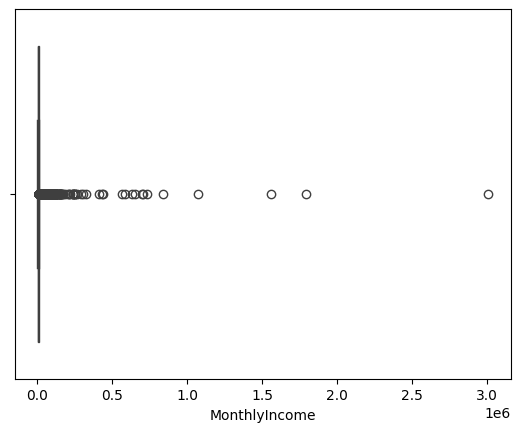

In [38]:
sns.boxplot(x=df['MonthlyIncome'])

## Stage 3 — Feature Engineering

 - Обрезать выбросы (clip)
 - Создать новые признаки: суммарные просрочки, debt-to-income, lines-per-age
 - Log-трансформация для скошенных признаков

In [39]:
df['RevolvingUtilizationOfUnsecuredLines'].max()

np.float64(50708.0)

In [40]:
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=1.0)
df["age"] = df["age"].clip(18, 100)

# DebtRatio — тоже должен быть ~0-1, но есть 329664
# Обрезаем до разумного максимума
df["DebtRatio"] = df["DebtRatio"].clip(0, 1)



In [41]:
income_99 = df["MonthlyIncome"].quantile(0.99)
df["MonthlyIncome"] = df["MonthlyIncome"].clip(0, income_99)




In [42]:
for col in ["NumberOfTime30-59DaysPastDueNotWorse",
            "NumberOfTime60-89DaysPastDueNotWorse",
            "NumberOfTimes90DaysLate"]:
    df[col] = df[col].clip(0, 10)

In [43]:
df["NumberRealEstateLoansOrLines"] = \
    df["NumberRealEstateLoansOrLines"].clip(0, 10)

In [44]:
df["NumberOfDependents"] = df["NumberOfDependents"].clip(0, 5)

print("✅ Выбросы обрезаны")
print(df.describe().T[["min", "max"]])

✅ Выбросы обрезаны
                                       min      max
target                                 0.0      1.0
RevolvingUtilizationOfUnsecuredLines   0.0      1.0
age                                   18.0    100.0
NumberOfTime30-59DaysPastDueNotWorse   0.0     10.0
DebtRatio                              0.0      1.0
MonthlyIncome                          0.0  23000.0
NumberOfOpenCreditLinesAndLoans        0.0     58.0
NumberOfTimes90DaysLate                0.0     10.0
NumberRealEstateLoansOrLines           0.0     10.0
NumberOfTime60-89DaysPastDueNotWorse   0.0     10.0
NumberOfDependents                     0.0      5.0
MonthlyIncome_missing_flag             0.0      1.0
NumberOfDependents_missing_flag        0.0      1.0


In [45]:
df["NumberOfDependents"] = df["NumberOfDependents"].clip(0, 5)


In [46]:
print(df.describe().T[["min", "max"]])

                                       min      max
target                                 0.0      1.0
RevolvingUtilizationOfUnsecuredLines   0.0      1.0
age                                   18.0    100.0
NumberOfTime30-59DaysPastDueNotWorse   0.0     10.0
DebtRatio                              0.0      1.0
MonthlyIncome                          0.0  23000.0
NumberOfOpenCreditLinesAndLoans        0.0     58.0
NumberOfTimes90DaysLate                0.0     10.0
NumberRealEstateLoansOrLines           0.0     10.0
NumberOfTime60-89DaysPastDueNotWorse   0.0     10.0
NumberOfDependents                     0.0      5.0
MonthlyIncome_missing_flag             0.0      1.0
NumberOfDependents_missing_flag        0.0      1.0


## 3.2 Feature Engineering 


✅ Выбросы обрезаны
                                       min      max
target                                 0.0      1.0
RevolvingUtilizationOfUnsecuredLines   0.0      1.0
age                                   18.0    100.0
NumberOfTime30-59DaysPastDueNotWorse   0.0     10.0
DebtRatio                              0.0      1.0
MonthlyIncome                          0.0  23000.0
NumberOfOpenCreditLinesAndLoans        0.0     58.0
NumberOfTimes90DaysLate                0.0     10.0
NumberRealEstateLoansOrLines           0.0     10.0
NumberOfTime60-89DaysPastDueNotWorse   0.0     10.0
NumberOfDependents                     0.0      5.0
MonthlyIncome_missing_flag             0.0      1.0
NumberOfDependents_missing_flag        0.0      1.0

✅ Новые признаки созданы:
                              mean          std  min           max
total_delinq              0.453787     1.664801  0.0     30.000000
has_any_delinq            0.202420     0.401805  0.0      1.000000
severe_delinq_ratio      

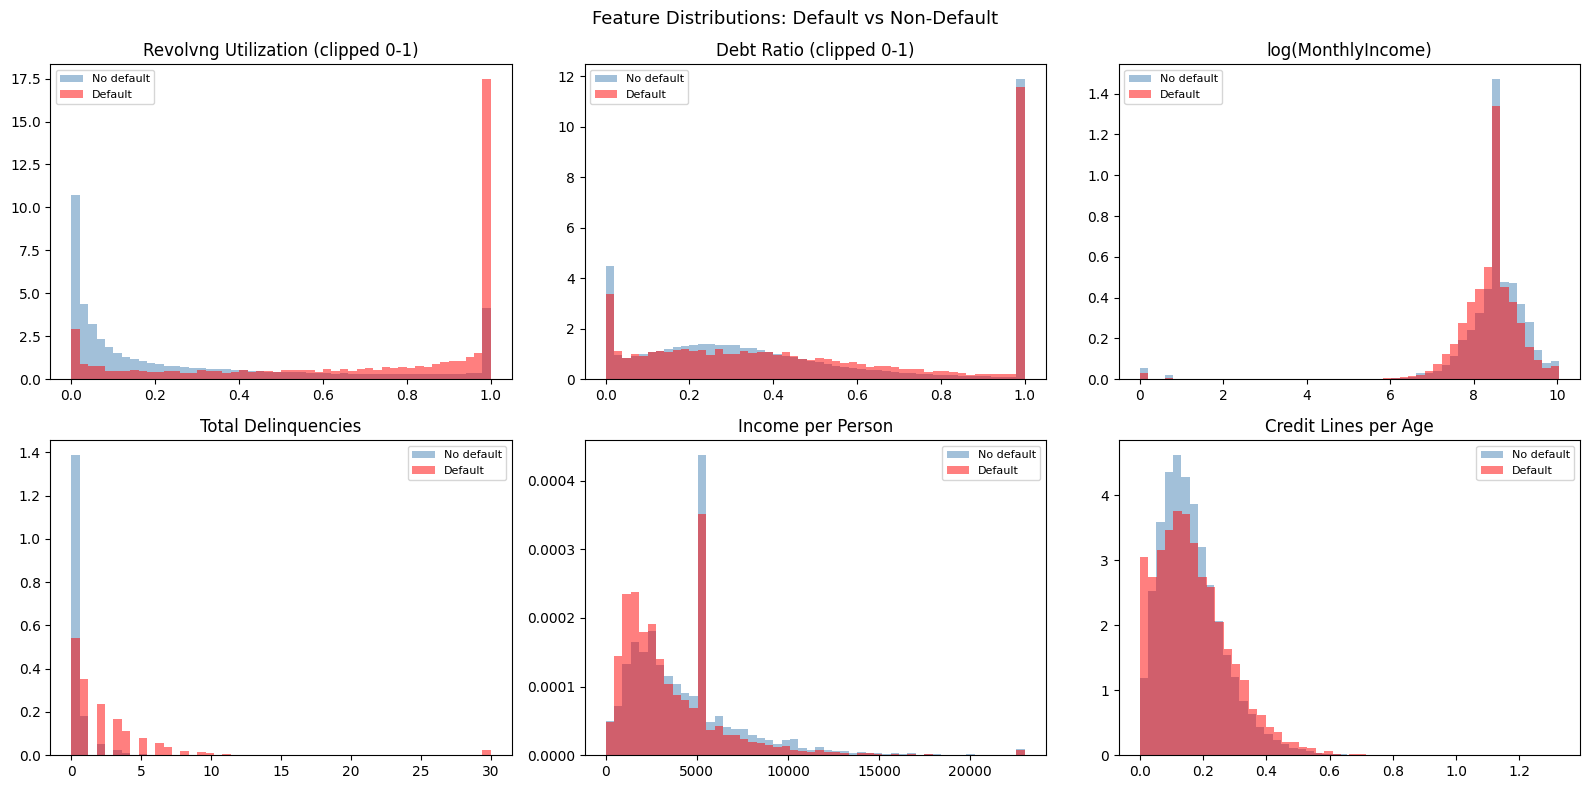


✅ Итого признаков после Feature Engineering: 27
['target', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'MonthlyIncome_missing_flag', 'NumberOfDependents_missing_flag', 'total_delinq', 'has_any_delinq', 'severe_delinq_ratio', 'monthly_debt', 'monthly_free_cash', 'income_per_person', 'lines_per_age', 'real_estate_ratio', 'age_group', 'log_MonthlyIncome', 'log_monthly_debt', 'log_income_per_person', 'log_monthly_free_cash', 'income_quartile']


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# ШАГ 1 — Clip выбросов
# =================================================================
# RevolvingUtilization — это доля использования кредитного лимита
# По определению должна быть 0-1, но есть значения 50000+
# Это либо ошибки ввода, либо технические коды → обрезаем до 1
df["RevolvingUtilizationOfUnsecuredLines"] = \
    df["RevolvingUtilizationOfUnsecuredLines"].clip(0, 1)

# age — 0 лет это явная ошибка, 109 — возможно реально но редко
df["age"] = df["age"].clip(18, 100)

# DebtRatio — тоже должен быть ~0-1, но есть 329664
# Обрезаем до разумного максимума
df["DebtRatio"] = df["DebtRatio"].clip(0, 1)

# MonthlyIncome — 3 миллиона это выброс, обрезаем до 99 перцентиля
income_99 = df["MonthlyIncome"].quantile(0.99)
df["MonthlyIncome"] = df["MonthlyIncome"].clip(0, income_99)

# Просрочки — значение 98 это технический код "98 или больше"
# Обрезаем до реалистичного максимума
for col in ["NumberOfTime30-59DaysPastDueNotWorse",
            "NumberOfTime60-89DaysPastDueNotWorse",
            "NumberOfTimes90DaysLate"]:
    df[col] = df[col].clip(0, 10)

# NumberRealEstateLoansOrLines — 54 это много, обрезаем
df["NumberRealEstateLoansOrLines"] = \
    df["NumberRealEstateLoansOrLines"].clip(0, 10)

# NumberOfDependents — 20 иждивенцев нереально
df["NumberOfDependents"] = df["NumberOfDependents"].clip(0, 5)

print("✅ Выбросы обрезаны")
print(df.describe().T[["min", "max"]])

# =================================================================
# ШАГ 2 — Новые признаки
# =================================================================

# ── Просрочки ─────────────────────────────────────────────────────
# Суммарное количество просрочек любой степени
df["total_delinq"] = (
    df["NumberOfTime30-59DaysPastDueNotWorse"] +
    df["NumberOfTime60-89DaysPastDueNotWorse"] +
    df["NumberOfTimes90DaysLate"]
)

# Есть ли хоть одна просрочка (бинарный флаг)
df["has_any_delinq"] = (df["total_delinq"] > 0).astype(int)

# Соотношение тяжёлых просрочек к лёгким
# Чем выше доля 90+ дней → тем хуже платёжная дисциплина
df["severe_delinq_ratio"] = (
    df["NumberOfTimes90DaysLate"] /
    (df["total_delinq"] + 1e-6)
)

# ── Долговая нагрузка ─────────────────────────────────────────────
# Абсолютный ежемесячный долг
df["monthly_debt"] = df["DebtRatio"] * df["MonthlyIncome"]

# Остаток после долгов
df["monthly_free_cash"] = df["MonthlyIncome"] - df["monthly_debt"]

# Доход на одного члена семьи (включая самого заёмщика)
df["income_per_person"] = (
    df["MonthlyIncome"] /
    (df["NumberOfDependents"] + 1)  # +1 это сам заёмщик
)

# ── Кредитная активность ──────────────────────────────────────────
# Кредитные линии на возраст — молодой с кучей кредитов = риск
df["lines_per_age"] = (
    df["NumberOfOpenCreditLinesAndLoans"] /
    (df["age"] + 1)
)

# Доля ипотечных кредитов в общем числе
df["real_estate_ratio"] = (
    df["NumberRealEstateLoansOrLines"] /
    (df["NumberOfOpenCreditLinesAndLoans"] + 1)
)

# ── Возрастные группы ─────────────────────────────────────────────
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 50, 65, 100],
    labels=["<25", "25-35", "35-50", "50-65", "65+"]
)

# ── Log трансформации (убираем скошенность) ───────────────────────
for col in ["MonthlyIncome", "monthly_debt",
            "income_per_person", "monthly_free_cash"]:
    df[f"log_{col}"] = np.log1p(df[col].clip(lower=0))

print("\n✅ Новые признаки созданы:")
new_features = [
    "total_delinq", "has_any_delinq", "severe_delinq_ratio",
    "monthly_debt", "monthly_free_cash", "income_per_person",
    "lines_per_age", "real_estate_ratio", "age_group",
    "log_MonthlyIncome", "log_monthly_debt",
    "log_income_per_person", "log_monthly_free_cash"
]
print(df[new_features].describe().T[["mean", "std", "min", "max"]])

# =================================================================
# ШАГ 3 — Проверка: DR по новым признакам
# =================================================================
print("\n── Default Rate по группам ──────────────────────────────────")

# DR по наличию просрочек
print("\nhas_any_delinq:")
print(df.groupby("has_any_delinq")["target"].mean().round(4))

# DR по возрастным группам
print("\nage_group:")
print(df.groupby("age_group", observed=True)["target"].mean().round(4))

# DR по квантилям дохода
df["income_quartile"] = pd.qcut(df["MonthlyIncome"], q=4,
                                 labels=["Q1","Q2","Q3","Q4"])
print("\nMonthlyIncome (квартили):")
print(df.groupby("income_quartile", observed=True)["target"].mean().round(4))

# =================================================================
# ШАГ 4 — Визуализация распределений ДО и ПОСЛЕ обрезки
# =================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

plot_pairs = [
    ("RevolvingUtilizationOfUnsecuredLines", "Revolvng Utilization (clipped 0-1)"),
    ("DebtRatio",                            "Debt Ratio (clipped 0-1)"),
    ("log_MonthlyIncome",                    "log(MonthlyIncome)"),
    ("total_delinq",                         "Total Delinquencies"),
    ("income_per_person",                    "Income per Person"),
    ("lines_per_age",                        "Credit Lines per Age"),
]

for ax, (col, title) in zip(axes.flat, plot_pairs):
    good = df[df["target"] == 0][col].dropna()
    bad  = df[df["target"] == 1][col].dropna()
    ax.hist(good, bins=50, alpha=0.5, color="steelblue",
            label="No default", density=True)
    ax.hist(bad,  bins=50, alpha=0.5, color="red",
            label="Default",    density=True)
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle("Feature Distributions: Default vs Non-Default", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n✅ Итого признаков после Feature Engineering: {df.shape[1]}")
print(df.columns.tolist())

## 4. OOT 

In [50]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
OOT_RATE = 0.2
VAL_RATE = 0.25

oot_start = int(len(df)* (1 - OOT_RATE))

trainval_df = df[:oot_start].copy().reset_index(drop=True)
oot_df = df[oot_start:].copy().reset_index(drop=True)


train_df, val_df = train_test_split(trainval_df, test_size=VAL_RATE, random_state=RANDOM_STATE, stratify=trainval_df['target'])

print(f'TRAIN DR: {train_df['target'].mean():.4f}')
print(f'VAL DR: {val_df['target'].mean():.4f}')
print(f'OOT DR: {oot_df['target'].mean():.4f}')



TRAIN DR: 0.0665
VAL DR: 0.0665
OOT DR: 0.0681


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# ШАГ 1 — Функция расчёта WOE и IV для одного признака
# =================================================================
def calc_woe_iv(df, feature, target, n_bins=10):
    """
    Считает WOE и IV для одного признака.
    Возвращает:
      - таблицу бинов с WOE
      - скалярное значение IV
    """
    tmp = df[[feature, target]].copy()

    N1 = tmp[target].sum()        # всего дефолтов
    N0 = (1 - tmp[target]).sum()  # всего не-дефолтов

    # Бинизация
    if pd.api.types.is_numeric_dtype(tmp[feature]):
        try:
            tmp["bin"] = pd.qcut(tmp[feature], q=n_bins, duplicates="drop")
        except Exception:
            tmp["bin"] = pd.cut(tmp[feature], bins=n_bins, duplicates="drop")
    else:
        # Категориальные — как есть
        tmp["bin"] = tmp[feature].astype(str)

    # Агрегация по бинам
    grp = (tmp.groupby("bin", observed=True)[target]
              .agg(["sum", "count"])
              .rename(columns={"sum": "events", "count": "total"}))
    grp["non_events"] = grp["total"] - grp["events"]

    # Доли с защитой от log(0)
    grp["pct_events"]     = (grp["events"]     / N1).clip(lower=1e-6)
    grp["pct_non_events"] = (grp["non_events"] / N0).clip(lower=1e-6)

    # WOE и IV
    grp["WOE"] = np.log(grp["pct_events"] / grp["pct_non_events"])
    grp["IV"]  = (grp["pct_events"] - grp["pct_non_events"]) * grp["WOE"]

    iv_total = round(grp["IV"].sum(), 4)

    return grp.round(4), iv_total


# =================================================================
# ШАГ 2 — Считаем IV для всех признаков (только на Train)
# =================================================================
# Список признаков для модели — исключаем target и категориальные
EXCLUDE = ["target", "age_group", "income_quartile"]
features_model = [c for c in train.columns
                  if c not in EXCLUDE
                  and pd.api.types.is_numeric_dtype(train[c])]

print(f"Признаков для анализа: {len(features_model)}")

iv_results = {}
for feat in features_model:
    try:
        _, iv = calc_woe_iv(train, feat, "target")
        iv_results[feat] = iv
    except Exception as e:
        print(f"  Ошибка [{feat}]: {e}")

# Сортируем по IV
iv_df = (pd.DataFrame
           .from_dict(iv_results, orient="index", columns=["IV"])
           .sort_values("IV", ascending=False))

# Категория силы
def iv_label(iv):
    if iv < 0.02:  return "🗑 Бесполезный"
    if iv < 0.10:  return "❌ Слабый"
    if iv < 0.30:  return "🟡 Средний"
    if iv < 0.50:  return "✅ Сильный"
    return "🔍 Проверь leakage"

iv_df["strength"] = iv_df["IV"].apply(iv_label)
print("\n── IV по признакам (Train) ───────────────────────────────────")
print(iv_df.to_string())

# =================================================================
# ШАГ 3 — Оставляем только признаки с IV >= 0.02
# =================================================================
IV_THRESH    = 0.02
keep_features = iv_df[iv_df["IV"] >= IV_THRESH].index.tolist()

print(f"\nОставляем признаков (IV ≥ {IV_THRESH}): {len(keep_features)}")
print(keep_features)

# =================================================================
# ШАГ 4 — Обучаем WOE таблицы на Train
# =================================================================
woe_tables = {}
for feat in keep_features:
    woe_tables[feat], _ = calc_woe_iv(train, feat, "target")

# =================================================================
# ШАГ 5 — WOE трансформация Train / Val / OOT
# =================================================================
def apply_woe(series, feature, woe_table, train_series):
    """
    Применяет WOE трансформацию к серии данных.
    Бины считаются по Train (train_series).
    """
    mapping = woe_table["WOE"].to_dict()

    if pd.api.types.is_numeric_dtype(series):
        # Получаем границы бинов с Train
        try:
            _, bins = pd.qcut(train_series, q=10,
                              duplicates="drop", retbins=True)
        except Exception:
            _, bins = pd.cut(train_series, bins=10,
                             duplicates="drop", retbins=True)

        bins[0]  = -np.inf
        bins[-1] =  np.inf
        binned = pd.cut(series, bins=bins, include_lowest=True)
        return binned.map(mapping)
    else:
        return series.astype(str).map(mapping)


woe_cols = []
for feat in keep_features:
    woe_col = f"{feat}_woe"
    woe_cols.append(woe_col)

    for split in [train, val, df_oot]:
        split[woe_col] = apply_woe(
            split[feat],
            feat,
            woe_tables[feat],
            train[feat]
        )

# Проверяем пропуски после трансформации
print("\n── Пропуски в WOE колонках ──────────────────────────────────")
missing_woe = train[woe_cols].isnull().sum()
missing_woe = missing_woe[missing_woe > 0]
if len(missing_woe) > 0:
    print(missing_woe)
    print("→ Заполняем пропуски нулём (нейтральный WOE)")
    for split in [train, val, df_oot]:
        split[woe_cols] = split[woe_cols].fillna(0)
else:
    print("Пропусков нет ✅")

# =================================================================
# ШАГ 6 — Визуализация
# =================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# График 1 — IV баров
colors = ["purple" if iv >= 0.5
          else "green"  if iv >= 0.3
          else "orange" if iv >= 0.1
          else "red"
          for iv in iv_df["IV"]]
ax1.barh(iv_df.index, iv_df["IV"], color=colors)
ax1.axvline(0.02, linestyle="--", color="red",    alpha=0.7, label="0.02 — минимум")
ax1.axvline(0.10, linestyle="--", color="orange", alpha=0.7, label="0.10 — слабый")
ax1.axvline(0.30, linestyle="--", color="green",  alpha=0.7, label="0.30 — средний")
ax1.set_xlabel("Information Value")
ax1.set_title("IV по признакам (Train)")
ax1.legend(fontsize=8)
ax1.invert_yaxis()

# График 2 — WOE таблица топ признака
top_feat = iv_df.index[0]
woe_tbl  = woe_tables[top_feat][["WOE"]].reset_index()
woe_tbl["bin_str"] = woe_tbl["bin"].astype(str)
colors2  = ["red" if w > 0 else "steelblue" for w in woe_tbl["WOE"]]
ax2.barh(woe_tbl["bin_str"], woe_tbl["WOE"], color=colors2)
ax2.axvline(0, color="black", linewidth=0.8)
ax2.set_xlabel("WOE")
ax2.set_title(f"WOE по бинам: {top_feat}\n(красный = выше риск, синий = ниже риск)")
ax2.invert_yaxis()

plt.suptitle("Stage 6 — WOE + IV", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n✅ WOE трансформация завершена")
print(f"   Признаков после IV фильтра: {len(keep_features)}")
print(f"   WOE колонок создано:        {len(woe_cols)}")